In [ ]:
!pip install xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

In [ ]:
uploaded = files.upload()

file_name = "MAI_GP_kc_house_data.xlsx"

df = pd.read_excel(file_name)

print("Dataset shape:", df.shape)
df.head()

Saving MAI_GP_kc_house_data.xlsx to MAI_GP_kc_house_data.xlsx
Dataset shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [ ]:
# Data Preprocessing
df_model = df.copy()

if 'date' in df_model.columns:
    df_model['date'] = pd.to_datetime(df_model['date'], errors='coerce')
    df_model['year'] = df_model['date'].dt.year
    df_model['month'] = df_model['date'].dt.month

drop_cols = ['id', 'date']
drop_cols = [col for col in drop_cols if col in df_model.columns]
df_model = df_model.drop(columns=drop_cols)

df_model = df_model.dropna()

if 'price' in df_model.columns:
    df_model = df_model[df_model['price'] > 0]

print("After preprocessing:", df_model.shape)
df_model.head()

After preprocessing: (21613, 21)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2


In [ ]:
target_col = 'price'

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print("Feature columns:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Feature columns:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'year', 'month']

X shape: (21613, 20)
y shape: (21613,)


In [ ]:
# Data Split 622
y_log = np.log1p(y)

# Step 1: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_log, test_size=0.4, random_state=42
)

# Step 2: 20% validation, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train shape      :", X_train.shape)
print("Validation shape :", X_val.shape)
print("Test shape       :", X_test.shape)

Train shape      : (12967, 20)
Validation shape : (4323, 20)
Test shape       : (4323, 20)


In [ ]:
def evaluate_regression(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    epsilon = 1e-8
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

    return r2, mae, rmse, mape

In [ ]:
common_params = {
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist'
}

In [ ]:
# Model A: without early stopping
model_no_es = XGBRegressor(
    n_estimators=500,
    **common_params
)

model_no_es.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

results_no_es = model_no_es.evals_result()

y_val_pred_no_es = model_no_es.predict(X_val)
y_test_pred_no_es = model_no_es.predict(X_test)

val_metrics_no_es = evaluate_regression(y_val, y_val_pred_no_es)
test_metrics_no_es = evaluate_regression(y_test, y_test_pred_no_es)


Model without Early Stopping trained successfully.


In [ ]:
# Model B: With early stopping
model_es = XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=20,
    **common_params
)

model_es.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

results_es = model_es.evals_result()

y_val_pred_es = model_es.predict(X_val)
y_test_pred_es = model_es.predict(X_test)

val_metrics_es = evaluate_regression(y_val, y_val_pred_es)
test_metrics_es = evaluate_regression(y_test, y_test_pred_es)


Model with Early Stopping trained successfully.


In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["No Early Stopping", "With Early Stopping"],
    "Val R2": [val_metrics_no_es[0], val_metrics_es[0]],
    "Val MAE": [val_metrics_no_es[1], val_metrics_es[1]],
    "Val RMSE": [val_metrics_no_es[2], val_metrics_es[2]],
    "Val MAPE": [val_metrics_no_es[3], val_metrics_es[3]],
    "Test R2": [test_metrics_no_es[0], test_metrics_es[0]],
    "Test MAE": [test_metrics_no_es[1], test_metrics_es[1]],
    "Test RMSE": [test_metrics_no_es[2], test_metrics_es[2]],
    "Test MAPE": [test_metrics_no_es[3], test_metrics_es[3]],
})

comparison_df

,Model,Val R2,Val MAE,Val RMSE,Val MAPE,Test R2,Test MAE,Test RMSE,Test MAPE
0,No Early Stopping,0.891377,63722.418364,119245.220828,11.728080,0.914230,63468.857074,120046.513293,11.623365
1,With Early Stopping,0.892691,63419.869960,118521.778184,11.688302,0.915778,63175.647993,118958.002996,11.586395


In [ ]:
print("Best iteration:", model_es.best_iteration)
print("Best validation score:", model_es.best_score)
print("Best iteration ratio:", round((model_es.best_iteration + 1) / 1000, 4))

Best iteration: 572
Best validation score: 0.16269733352201673
Best iteration ratio: 0.573


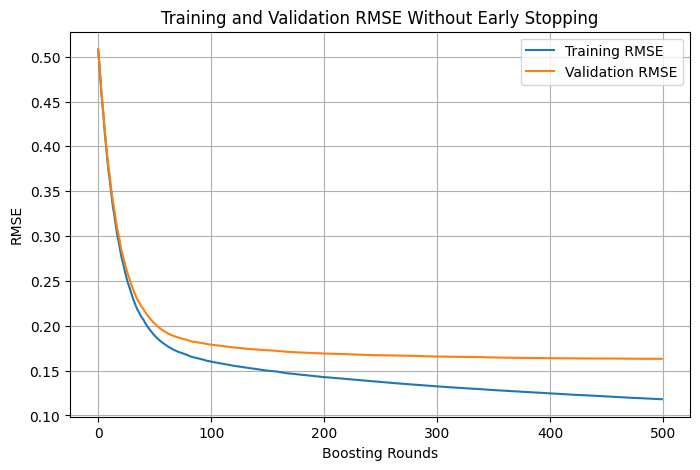

In [ ]:
# without early stopping  RMSE
train_rmse_no_es = results_no_es['validation_0']['rmse']
val_rmse_no_es = results_no_es['validation_1']['rmse']

plt.figure(figsize=(8, 5))
plt.plot(train_rmse_no_es, label="Training RMSE")
plt.plot(val_rmse_no_es, label="Validation RMSE")
plt.title("Training and Validation RMSE Without Early Stopping")
plt.xlabel("Boosting Rounds")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

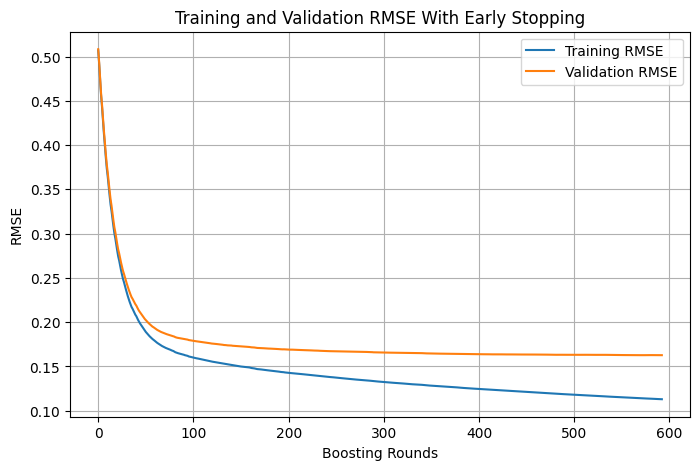

In [ ]:
# with early stopping RMSE
train_rmse_es = results_es['validation_0']['rmse']
val_rmse_es = results_es['validation_1']['rmse']

plt.figure(figsize=(8, 5))
plt.plot(train_rmse_es, label="Training RMSE")
plt.plot(val_rmse_es, label="Validation RMSE")
plt.title("Training and Validation RMSE With Early Stopping")
plt.xlabel("Boosting Rounds")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

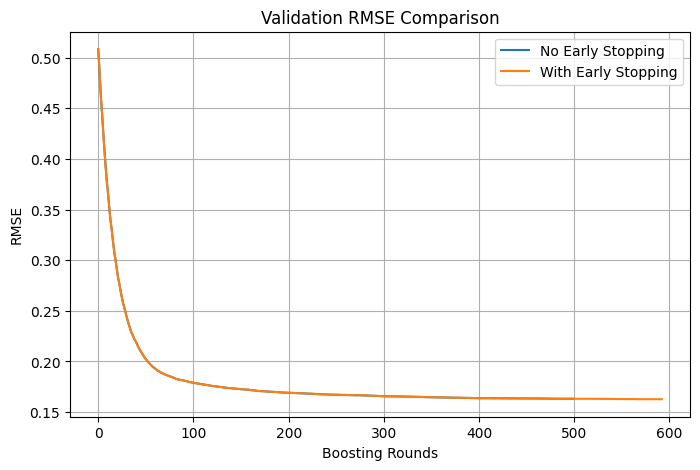

In [ ]:
# Validation RMSE comparison diagram
plt.figure(figsize=(8, 5))
plt.plot(val_rmse_no_es, label="No Early Stopping")
plt.plot(val_rmse_es, label="With Early Stopping")
plt.title("Validation RMSE Comparison")
plt.xlabel("Boosting Rounds")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

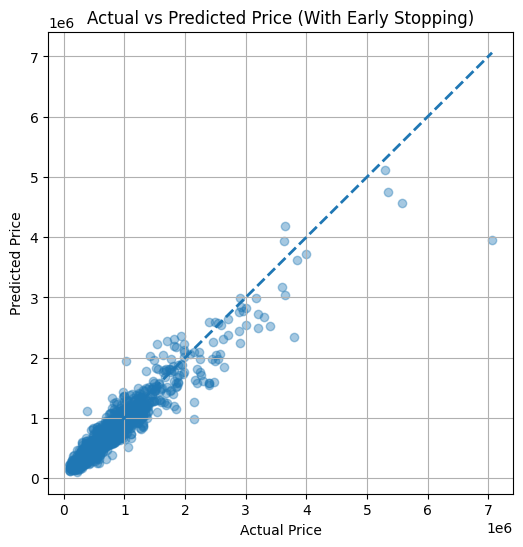

In [ ]:
# Scatter plot of test set real vs. predicted with early stopping
y_test_true = np.expm1(y_test)
y_test_pred = np.expm1(model_es.predict(X_test))

plt.figure(figsize=(6, 6))
plt.scatter(y_test_true, y_test_pred, alpha=0.4)
plt.plot(
    [y_test_true.min(), y_test_true.max()],
    [y_test_true.min(), y_test_true.max()],
    '--',
    linewidth=2
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (With Early Stopping)")
plt.grid(True)
plt.show()

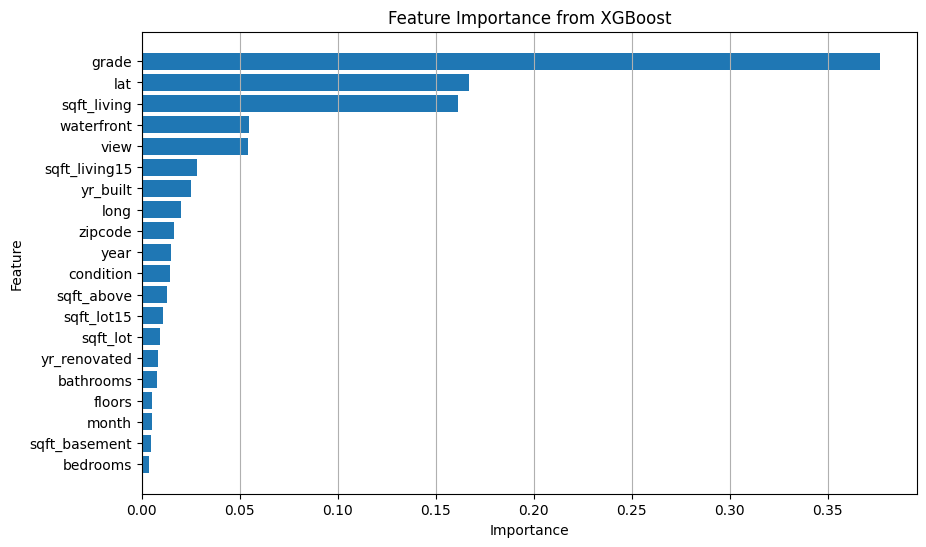

In [ ]:
# Feature importance map
feature_importance = pd.Series(
    model_es.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance.index, feature_importance.values)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance from XGBoost")
plt.gca().invert_yaxis()
plt.grid(True, axis='x')
plt.show()